In [1]:
# open pickle files of numpy data and plot examples. The numpy data is in 3D arrays of shape (timestep, x, y) where the value is the exposure rate as determined by delfic
import numpy as np
import matplotlib.pyplot as plt
import pickle

sourceDirectory = './delfic_test/'

#build a list of all the folders in the source directory
import os
folders = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

#the folder name contains the metadata for the data, the format is dynamic based off the following code
# self.run_name = f"Y{int(self.blast_yield)}H{int(self.burst_height)}"
# self.run_name += f"SS{int(self.surface_wind_speed)}DS{int(self.surface_wind_direction)}"
# self.run_name += f"SA{int(self.winds_aloft_max)}BA{int(self.boundary_alt)}"
# the run_name becomes the folder name

folder: Y100H0SS5DS345SA20BA6672 576
(24, 512, 512)


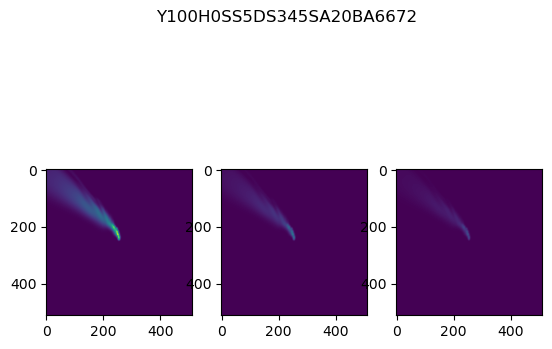

In [2]:
#use a random folder to open the pickle file and get the metadata
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}", idx)
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)
    print(data.shape)

#plot the data for the first three timesteps
# use the same scale on the colorbar for all plots
#find the max and min of the data
maxVal = np.max(data)
minVal = np.min(data)
plt.figure()
plt.subplot(131)
plt.imshow(data[0], vmin=minVal, vmax=maxVal)
plt.subplot(132)
plt.imshow(data[1], vmin=minVal, vmax=maxVal)
plt.subplot(133)
plt.imshow(data[2], vmin=minVal, vmax=maxVal)
#provide a super label using the folder name
plt.suptitle(folder)
plt.show()

In [733]:
from math import trunc
import matplotlib.colors as mcolors

def uniform_sample_ellipse(a, b, theta, num_points):
    """
    Uniformly sample points from an ellipse.
    
    Parameters:
    a (float): Semi-major axis
    b (float): Semi-minor axis
    theta (float): Rotation angle of the ellipse (in radians)
    num_points (int): Number of points to sample
    
    Returns:
    np.ndarray: Sampled points (num_points, 2)
    """
    # Generate uniform points in a unit circle
    angles = np.random.uniform(0, 2 * np.pi, num_points)
    radii = np.sqrt(np.random.uniform(0, 1, num_points))
    
    # Convert to Cartesian coordinates
    x_unit = radii * np.cos(angles)
    y_unit = radii * np.sin(angles)
    
    # Scale points to the ellipse
    x_ellipse = a * x_unit
    y_ellipse = b * y_unit
    
    # Rotate points by theta
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    x_rot = cos_theta * x_ellipse - sin_theta * y_ellipse
    y_rot = sin_theta * x_ellipse + cos_theta * y_ellipse
    
    # Combine and return
    return np.vstack((x_rot, y_rot)).T

def getSCRAMfield(idx=None, plot=False, numArtyShells=10):
    if idx is None:
        idx = np.random.randint(len(folders))

    folder = folders[idx]
    print(f"folder: {folder}, idx: {idx}")
    with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
        data = pickle.load(f)

    #the blast is at the center of the image, look at the first timestep to determine the axis of fallout pattern
    #flatten the data
    data = data[0]

    #reduce the data from 512x512 to 50x50, taking only the data from the center of the image
    truncDataScale = 50
    truncDataLowerLimit = data.shape[0]//2 - truncDataScale//2 
    trunc_data = data[truncDataLowerLimit:truncDataLowerLimit+truncDataScale, truncDataLowerLimit:truncDataLowerLimit+truncDataScale]

    # Define a threshold for significant traffic
    minThreshold = 0.1 * np.max(trunc_data)
    maxThreshold = 0.9 * np.max(trunc_data)
    # apply the min and max threshold
    falloutIndices = np.nonzero((trunc_data > minThreshold) & (trunc_data < maxThreshold))
    falloutX = np.array(falloutIndices[1])
    falloutY = np.array(falloutIndices[0])
    weights = trunc_data[falloutY, falloutX]  # Use traffic density as weights

    # Calculate the center of the grid
    truncCenterX = (trunc_data.shape[1] - 1) / 2
    truncCenterY = (trunc_data.shape[0] - 1) / 2

    # Convert to polar coordinates relative to the center
    angles = np.arctan2(falloutY - truncCenterY, falloutX - truncCenterX)

    # Compute the weighted average angle
    falloutDir = np.arctan2(np.sum(np.sin(angles) * weights), np.sum(np.cos(angles) * weights))

    # Create a line based on the average angle
    line_length = max(trunc_data.shape)
    falloutX = truncCenterX + line_length * np.array([0, np.cos(falloutDir)])
    falloutY = truncCenterY + line_length * np.array([0, np.sin(falloutDir)])

    #shift the line to the center of the image
    falloutX += truncDataLowerLimit
    falloutY += truncDataLowerLimit

    # determine the angle of a line that is perpendicular to the fallout direction
    perpendicular_angle = falloutDir + np.pi / 2

    # determine a line that is x pixels long perpendicular to the fallout direction, 
    # with the midpoint of the line at the center of the image
    detectorFieldLength = 10 # 1km
    detFieldLengthX = truncCenterX + (detectorFieldLength/2) * np.array([np.cos(perpendicular_angle), -np.cos(perpendicular_angle)]) + truncDataLowerLimit
    detFieldLengthY = truncCenterY + (detectorFieldLength/2) * np.array([np.sin(perpendicular_angle), -np.sin(perpendicular_angle)]) + truncDataLowerLimit

    # translate the perpendicular line along the fallout direction by 20 units
    detectorFieldDistance = np.random.uniform(2, 50)
    detFieldLengthX += detectorFieldDistance * np.cos(falloutDir)
    detFieldLengthY += detectorFieldDistance * np.sin(falloutDir)

    # determine the center of the detector field
    detectorFieldCenterX = truncCenterX + truncDataLowerLimit + detectorFieldDistance * np.cos(falloutDir)
    detectorFieldCenterY = truncCenterY + truncDataLowerLimit + detectorFieldDistance * np.sin(falloutDir)

    #determine the location of 4 gateways that are between 5 and 8 units from the center of the detector field, at least x units apart and have a weight below 100
    minSeperation = 5 # 500m
    exposureThreshold = 100
    gatewayLocations = []
    for i in range(4):
        searching = True
        attemptCounter = 0
        while searching:
            gatewayDistance = np.random.uniform(5, 8)
            gatewayAngle = np.random.uniform(0, 2*np.pi)
            gatewayX = truncCenterX + gatewayDistance * np.cos(gatewayAngle) + truncDataLowerLimit + detectorFieldDistance * np.cos(falloutDir)
            gatewayY = truncCenterY + gatewayDistance * np.sin(gatewayAngle) + truncDataLowerLimit + detectorFieldDistance * np.sin(falloutDir)
            if all(np.sqrt((gatewayX - gateway[0])**2 + (gatewayY - gateway[1])**2) > minSeperation for gateway in gatewayLocations) & (data[trunc(gatewayY), trunc(gatewayX)] < exposureThreshold):
                gatewayLocations.append((gatewayX, gatewayY))
                break
            attemptCounter += 1

            if attemptCounter > 100:
                exposureThreshold += 100
                attemptCounter = 0
                break
        

    #determine the location of the artillery firing point, 200-300 units (20-30km) from the center of the detector field
    artilleryDistance = np.random.uniform(200, 300)
    artilleryDirection = np.random.uniform(0, 2*np.pi)
    artilleryX = truncCenterX + artilleryDistance * np.cos(artilleryDirection) + truncDataLowerLimit
    artilleryY = truncCenterY + artilleryDistance * np.sin(artilleryDirection) + truncDataLowerLimit

    # determine the detector dispersion points
    detectorFieldWidth = 2 # 200m
    detectorFieldHeight = 8 # 800m
    dispersionPoints = uniform_sample_ellipse(detectorFieldWidth, detectorFieldHeight, falloutDir, numArtyShells)

    #shift the dispersion points to the center of the detector field
    dispersionPoints += np.array([detectorFieldCenterX, detectorFieldCenterY])

    # for each of the dispersion points, scatter n detectors around the point where the major axis is the direction from the artillery to the detector field center
    nDetectors = 24
    dispersionLength = 4 # 400m
    dispersionWidth = 1 # 100m

    detectors = []
    for artyShell in dispersionPoints:
        #determine the rotation angle of the detector field so that the major axis is the direction from the artillery to the detector field center
        detectorFieldAngle = np.arctan2(artilleryY - artyShell[1], artilleryX - artyShell[0])

        #determine the points of the detector field
        detectorFieldPoints = uniform_sample_ellipse(dispersionWidth, dispersionLength, detectorFieldAngle, nDetectors)

        #shift the detector field points to the arty shell
        detectorFieldPoints += artyShell

        for detector in detectorFieldPoints:
            detectors.append(detector)

    if plot:
        #create a custom colormap where zero is white
        cmap = plt.cm.jet
        cmaplist = [cmap(i) for i in range(cmap.N)]
        cmaplist[0] = (1, 1, 1, 1.0)
        cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)

        # Plotting

        # show the data
        plt.imshow(data, origin='lower', cmap=cmap, alpha=0.5)
        plt.colorbar(label='Fallout Density')

        # show the fallout direction
        plt.plot(falloutX, falloutY, 'r-', label='Fallout Direction')

        # show the orientation of the detector field
        plt.plot(detFieldLengthX, detFieldLengthY, 'g-', label='Detector Field')

        # plot the limits of gateway locations
        gatewayMax = plt.Circle((detectorFieldCenterX, detectorFieldCenterY), 8, color='black', fill=False)
        gatewayMin = plt.Circle((detectorFieldCenterX, detectorFieldCenterY), 5, color='black', fill=False)
        plt.gca().add_artist(gatewayMax)
        plt.gca().add_artist(gatewayMin)

        # plot the gateway locations
        gatewayHandle = plt.plot([gateway[0] for gateway in gatewayLocations], [gateway[1] for gateway in gatewayLocations], 'k+', label='Gateways', markersize=10, markeredgewidth=2, markeredgecolor='black')

        # plot the artillery firing point
        ArtyFPHandle = plt.plot(artilleryX, artilleryY, 'b+', label='Artillery')

        # plot the detector dispersion points
        DispersionHandle = plt.plot(dispersionPoints[:, 0], dispersionPoints[:, 1], 'kx', label='Dispersion Points')

        legendHandles = [gatewayMax, gatewayHandle[0], ArtyFPHandle[0], DispersionHandle[0]]
        legendLabels = ['Gateway Limits', 'Gateways', 'Artillery FP', 'Dispersion Points']
        plt.legend(legendHandles, legendLabels)

        # add a 1km square grid to the plot, 10 units per km
        plt.grid(which='both', color='black', linestyle='-', linewidth=0.5)
        ax = plt.gca()
        ax.set_xticks(np.arange(0, data.shape[1], 10))
        ax.set_yticks(np.arange(0, data.shape[0], 10))

        plotLimits = 100
        plt.xlim(data.shape[1]//2 - plotLimits/2, data.shape[1]//2 + plotLimits/2)
        plt.ylim(data.shape[0]//2 - plotLimits/2, data.shape[0]//2 + plotLimits/2)
        plt.show()

        ##########################################################################

        # Plotting

        # show the data
        plt.imshow(data, origin='lower', cmap=cmap, alpha=0.5)
        plt.colorbar(label='Fallout Density')

        # show the fallout direction
        plt.plot(falloutX, falloutY, 'r-', label='Fallout Direction')

        # show the orientation of the detector field
        plt.plot(detFieldLengthX, detFieldLengthY, 'g-', label='Detector Field')

        # plot the limits of gateway locations
        gatewayMax = plt.Circle((detectorFieldCenterX, detectorFieldCenterY), 8, color='black', fill=False)
        gatewayMin = plt.Circle((detectorFieldCenterX, detectorFieldCenterY), 5, color='black', fill=False)
        plt.gca().add_artist(gatewayMax)
        plt.gca().add_artist(gatewayMin)

        # plot the gateway locations
        plt.plot([gateway[0] for gateway in gatewayLocations], [gateway[1] for gateway in gatewayLocations], 'k+', label='Gateways', markersize=10, markeredgewidth=2, markeredgecolor='black')

        # plot the artillery firing point
        plt.plot(artilleryX, artilleryY, 'b+', label='Artillery')

        # plot the detectors
        detectorHandle = plt.plot([detector[0] for detector in detectors], [detector[1] for detector in detectors], 'ro', label='Detectors', alpha=0.5)

        # plot the detector dispersion points
        plt.plot(dispersionPoints[:, 0], dispersionPoints[:, 1], 'kx', label='Dispersion Points')

        legendHandles = [gatewayMax, gatewayHandle[0], DispersionHandle[0], detectorHandle[0]]
        legendLabels = ['Gateway Limits', 'Gateways', 'Dispersion Points', 'Detectors']
        plt.legend(legendHandles, legendLabels)

        # add a 1km square grid to the plot, 10 units per km
        plt.grid(which='both', color='black', linestyle='-', linewidth=0.5)
        ax = plt.gca()
        ax.set_xticks(np.arange(0, data.shape[1], 10))
        ax.set_yticks(np.arange(0, data.shape[0], 10))

        plotLimits = 25
        plt.xlim(detectorFieldCenterX - plotLimits/2, detectorFieldCenterX + plotLimits/2)
        plt.ylim(detectorFieldCenterY - plotLimits/2, detectorFieldCenterY + plotLimits/2)
        plt.show()

    return idx, gatewayLocations, detectors

folder: Y10H18SS6DS164SA22BA4000, idx: 1520


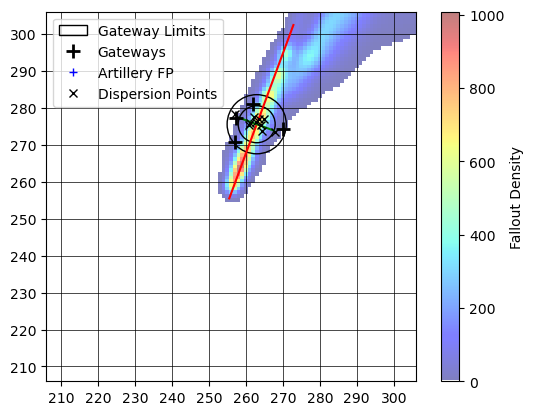

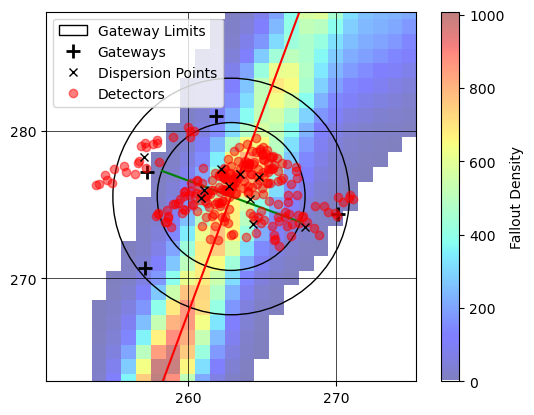

(1520,
 [(np.float64(257.199028723271), np.float64(277.18100950295616)),
  (np.float64(257.09819463559506), np.float64(270.67992439868726)),
  (np.float64(261.89107512979444), np.float64(280.9879147645484)),
  (np.float64(270.1410619879242), np.float64(274.33317217181167))],
 [array([263.41754662, 278.90483202]),
  array([259.4741266 , 275.40453374]),
  array([262.38777395, 276.84776685]),
  array([263.48478975, 277.41570452]),
  array([265.08581287, 278.35047876]),
  array([262.08528054, 276.94733611]),
  array([259.79946826, 275.90108057]),
  array([265.35437455, 278.68056759]),
  array([260.22856689, 275.91824868]),
  array([261.03222634, 277.49875956]),
  array([262.09273627, 276.99124663]),
  array([264.14618001, 277.76002523]),
  array([263.96236145, 279.10404598]),
  array([264.06749083, 277.78892499]),
  array([265.08771784, 278.91358802]),
  array([264.29463709, 278.62902482]),
  array([264.86707415, 278.59059151]),
  array([264.62537066, 279.5278119 ]),
  array([260.96332921,

In [738]:
getSCRAMfield(plot=True, numArtyShells=10)